In [23]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import skfuzzy as fuzz
from sklearn.model_selection import train_test_split

# ============================
# FIX RANDOMNESS HERE
# ============================
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
# ============================

## Function: `fcm_initialize(X, K, m=2.0)`

**Inputs:**

* `X`: Data array of shape $(N, n_\text{inputs})$ (samples × features)
* `K`: Number of clusters / fuzzy rules
* `m$: Fuzziness parameter (default $m=2$; larger → fuzzier membership)

**Outputs:**

* `centers`: $(K, n_\text{inputs})$ — cluster centers, used as Gaussian MF centers $m_j^i$
* `spreads`: $(K, n_\text{inputs})$ — cluster-wise standard deviations, used as Gaussian MF widths $\sigma_j^i$

---

## Steps

1. **Transpose data**: $X^\top$ → shape $(n_\text{inputs}, N)$ for `skfuzzy.cmeans`.

2. **Run FCM**:
   
   $$(u, \text{centers}) = \text{cmeans}(X^\top, c=K, m=m, \dots)$$

   * $u$ contains membership degrees of each sample to each cluster.
   * `centers` are the cluster centroids.

3. **Compute spreads** for each cluster $i$ and input $j$:
   $$\sigma_j^i = \sqrt{\frac{\sum_{n=1}^{N} u_{in} (x_{nj} - m_j^i)^2}{\sum_{n=1}^{N} u_{in}}}$$

   * Weighted variance of each feature per cluster.
   * Ensures initial Gaussian MF width reflects cluster dispersion.

4. **Clip spreads**:

   * Avoid extremely small values that may cause numerical instability:
     $$\sigma_j^i = \max(\sigma_j^i, 10^{-3})$$

---


In [24]:
# ---------------------------
# 1) Fuzzy C-Means for Initialization
# ---------------------------

def fcm_initialize(X, K, m=2.0):
    """
    X: numpy array shape (N, n_inputs)
    K: number of clusters / rules
    Returns:
        centers: (K, n_inputs)
        spreads: (K, n_inputs) -- std dev per cluster per input (clipped to avoid zero)
    """
    # skfuzzy cmeans expects data shaped (features, samples)
    X_t = X.T  # (n_inputs, N)
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        X_t,
        c=K,
        m=m,
        error=1e-5,
        maxiter=2000,
        init=None,
    )
    # cntr shape: (K, n_inputs)
    N = X.shape[0]
    n_inputs = X.shape[1]

    spreads = []
    for k in range(K):
        weights = u[k]            # (N,)
        w = weights.reshape(N, 1) # (N,1)

        diff = X - cntr[k]        # (N, n_inputs)
        # weighted variance per feature
        denom = np.sum(w) + 1e-12
        var = np.sum(w * (diff ** 2), axis=0) / denom
        spread = np.sqrt(var)
        spreads.append(spread)

    spreads = np.array(spreads)  # (K, n_inputs)

    # Clip spreads to avoid extremely small values which cause numerical issues
    spreads = np.clip(spreads, 1e-3, None)

    return np.array(cntr), spreads


In [25]:
# ---------------------------
# 2) Prepare Mackey-Glass Dataset
# ---------------------------
beta = 0.2
tau = 17.0
gamma = 0.1
n = 10.0
dt = 0.1

delay = int(tau / dt)
init_value = 1.2
T = 1000.0
num_steps = int(T / dt)

x = np.zeros(num_steps)
x[:delay] = init_value
time = np.arange(num_steps) * dt

for t in range(delay, num_steps - 1):
    feedback = (beta * x[t - delay]) / (1 + (x[t - delay]) ** n)
    x[t + 1] = x[t] + dt * (feedback - gamma * x[t])

# we'll consider only positions after 'delay' to build lagged dataset
time_pos = time[delay:]      # times aligned with x_pos
x_pos = x[delay:]            # series aligned with time_pos

# choose lags (in steps)
lags = [24, 18, 12, 6]  # these are indexes (assume dt=0.1 => these are 2.4s, 1.8s, ...)
max_lag = max(lags)

X, y = [], []
for t in range(max_lag, len(x_pos)):
    X.append([x_pos[t - lag] for lag in lags])
    y.append(x_pos[t])

X = np.array(X, dtype=np.float32)           # shape (samples, n_inputs)
y = np.array(y, dtype=np.float32).reshape(-1, 1)  # shape (samples, 1)



In [26]:
# ---------------------------
# 3) Train/Test Split (time-series split: no shuffle)
# ---------------------------
test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, shuffle=False
)

# time arrays for plotting (aligned to X,y)
time_full = time_pos[max_lag:]            # length matches len(X)
time_train = time_full[: len(X_train)]
time_test = time_full[len(X_train):]

# Convert to torch tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_tensor = torch.from_numpy(X_train).to(device)
y_train_tensor = torch.from_numpy(y_train).to(device)
X_test_tensor = torch.from_numpy(X_test).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

n_inputs = X.shape[1]
K = 9  # number of rules / clusters


In [27]:
# ---------------------------
# 4) FCM Initialization
# ---------------------------
centers_init, spreads_init = fcm_initialize(X_train, K)

In [28]:
# ---------------------------
# 5) Gaussian MF Layer
# ---------------------------
class GaussianMF_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        # centers_init: (K, n_inputs), spreads_init: (K, n_inputs)
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        # store as parameters so optimizer can tune them
        self.centers = nn.Parameter(torch.tensor(centers_init, dtype=torch.float32))
        # store spreads as positive parameters: store log_sigma to keep positivity
        # but to minimize changes, we'll store spreads directly and enforce positivity via softplus in forward
        self.spreads = nn.Parameter(torch.tensor(spreads_init, dtype=torch.float32))

    def forward(self, x):
        # x: (batch, n_inputs)
        # expand
        x_exp = x.unsqueeze(1)                       # (batch, 1, n_inputs)
        c_exp = self.centers.unsqueeze(0)            # (1, K, n_inputs)
        s_exp = torch.nn.functional.softplus(self.spreads).unsqueeze(0)  # (1, K, n_inputs) positive

        # Gaussian MF: exp(- (x-c)^2 / (2*s^2) )
        # prevent division by zero
        s_exp = torch.clamp(s_exp, min=1e-6)

        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2.0 * (s_exp ** 2)))  # (batch, K, n_inputs)

        # Combine (AND) across inputs by product
        firing = torch.prod(mu, dim=2)  # (batch, K)

        return firing


In [29]:
# ---------------------------
# 6) ANFIS Model With FCM Initialization
# ---------------------------
class ANFIS_FCM(nn.Module):
    def __init__(self, centers_init, spreads_init):
        super().__init__()
        self.K = centers_init.shape[0]
        self.n_inputs = centers_init.shape[1]

        self.mf_layer = GaussianMF_FCM(centers_init, spreads_init)

        # One linear function per rule: coefficients for inputs and a bias
        # shape: (K, n_inputs + 1)
        self.consequents = nn.Parameter(torch.randn(self.K, self.n_inputs + 1, dtype=torch.float32) * 0.1)

    def forward(self, x):
        # x: (batch, n_inputs)
        w = self.mf_layer(x)  # (batch, K)
        w_sum = torch.sum(w, dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum    # (batch, K)

        # compute rule outputs: y_r for each rule and batch
        # x_exp: (batch, K, n_inputs)
        x_exp = x.unsqueeze(1).expand(-1, self.K, -1)
        # consequents[:, :-1]: (K, n_inputs)
        # will broadcast to (batch, K, n_inputs)
        # Multiply and sum over inputs:
        # First expand consequents to (1, K, n_inputs)
        cons_w = self.consequents[:, :-1].unsqueeze(0)  # (1, K, n_inputs)
        linear_part = torch.sum(x_exp * cons_w, dim=2)   # (batch, K)
        bias = self.consequents[:, -1].unsqueeze(0)     # (1, K)
        y_r = linear_part + bias                        # (batch, K)

        # defuzzify / aggregate
        y_pred = torch.sum(w_norm * y_r, dim=1, keepdim=True)  # (batch, 1)
        return y_pred


Epoch 1/2000  Train MSE: 8.495791e-01  Test MSE: 8.983617e-01
Epoch 200/2000  Train MSE: 3.611357e-02  Test MSE: 3.857864e-02
Epoch 400/2000  Train MSE: 2.599763e-03  Test MSE: 2.939878e-03
Epoch 600/2000  Train MSE: 2.281270e-03  Test MSE: 2.621465e-03
Epoch 800/2000  Train MSE: 2.158856e-03  Test MSE: 2.499622e-03
Epoch 1000/2000  Train MSE: 2.087948e-03  Test MSE: 2.422645e-03
Epoch 1200/2000  Train MSE: 2.021990e-03  Test MSE: 2.346206e-03
Epoch 1400/2000  Train MSE: 1.948802e-03  Test MSE: 2.259797e-03
Epoch 1600/2000  Train MSE: 1.865212e-03  Test MSE: 2.161292e-03
Epoch 1800/2000  Train MSE: 1.770065e-03  Test MSE: 2.050420e-03
Epoch 2000/2000  Train MSE: 1.663768e-03  Test MSE: 1.928384e-03

Final results:
Train MSE: 0.0016637682
Train RMSE: 0.040789314
Test MSE: 0.0019283842
Test RMSE: 0.04391337


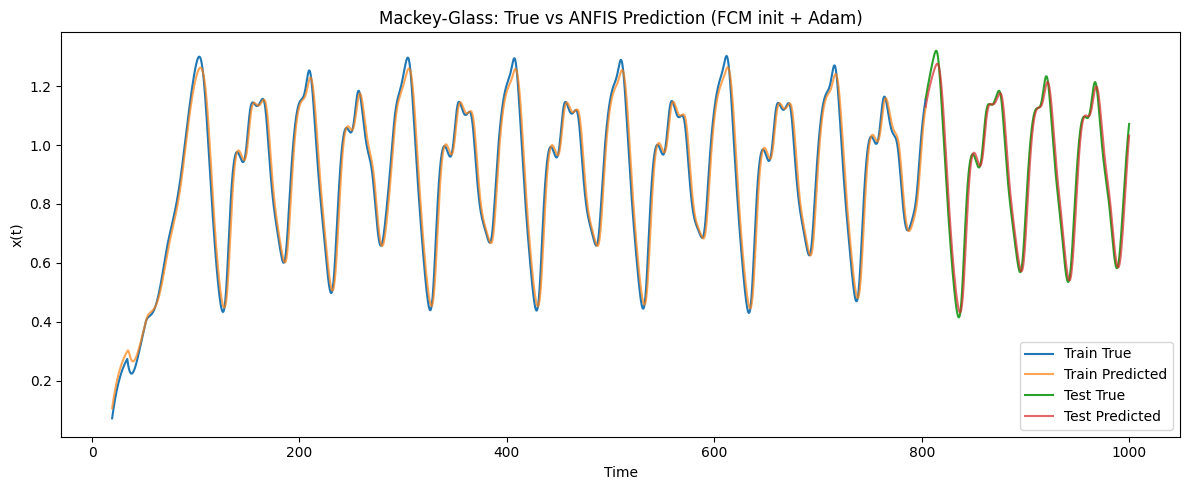

In [32]:
# ---------------------------
# 7) Training
# ---------------------------
model = ANFIS_FCM(centers_init, spreads_init).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

n_epochs = 2000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    y_pred_train = model(X_train_tensor)            # (n_train, 1)
    loss = loss_fn(y_pred_train, y_train_tensor)
    loss.backward()

    # gradient clipping for stability
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

    optimizer.step()

    # track best
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # print progress occasionally
    if epoch % 200 == 0 or epoch == 1:
        with torch.no_grad():
            model.eval()
            y_train_pred = model(X_train_tensor)
            train_mse = loss_fn(y_train_pred, y_train_tensor).item()
            # evaluate test performance
            y_test_pred = model(X_test_tensor)
            test_mse = loss_fn(y_test_pred, y_test_tensor).item()
        print(f"Epoch {epoch}/{n_epochs}  Train MSE: {train_mse:.6e}  Test MSE: {test_mse:.6e}")

# restore best model state (optional)
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    y_pred_train_tensor = model(X_train_tensor)
    y_pred_test_tensor = model(X_test_tensor)

y_pred_train_np = y_pred_train_tensor.cpu().numpy().reshape(-1)
y_pred_test_np = y_pred_test_tensor.cpu().numpy().reshape(-1)
y_train_np = y_train.reshape(-1)
y_test_np = y_test.reshape(-1)

test_mse = np.mean((y_test_np - y_pred_test_np) ** 2)
test_rmse = np.sqrt(test_mse)
train_mse = np.mean((y_train_np - y_pred_train_np) ** 2)
train_rmse = np.sqrt(train_mse)

print("\nFinal results:")
print("Train MSE:", train_mse)
print("Train RMSE:", train_rmse)
print("Test MSE:", test_mse)
print("Test RMSE:", test_rmse)

# ---------------------------
# 8) Plot results (train + test)
# ---------------------------
plt.figure(figsize=(12, 5))
plt.plot(time_train, y_train_np, label="Train True")
plt.plot(time_train, y_pred_train_np, label="Train Predicted", alpha=0.7)
plt.plot(time_test, y_test_np, label="Test True")
plt.plot(time_test, y_pred_test_np, label="Test Predicted", alpha=0.7)
plt.xlabel("Time")
plt.ylabel("x(t)")
plt.title("Mackey-Glass: True vs ANFIS Prediction (FCM init + Adam)")
plt.legend()
plt.tight_layout()
plt.show()
